In [150]:
import pandas as pd
import numpy as np

In [151]:
df = pd.read_csv("/kaggle/input/datasets/radhikaasmar/powerplant-data/powerplant_data.csv")

In [152]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [153]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [154]:
df.shape

(9568, 5)

In [155]:
# AT - temperature
# V - vaccum
# AP - pressure
# RH - humidity
# PE - produced energy

In [156]:
X = df.drop("PE", axis=1)
y= df["PE"]

In [157]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [158]:
#Split data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [159]:
X_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [160]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

X_test_scaled

array([[ 1.36255441,  0.24305848, -1.27798491, -1.04586379],
       [ 0.82147733,  1.36986442, -0.74695303,  0.31071896],
       [-0.247116  , -0.73708132,  1.92304887, -0.14668594],
       ...,
       [-0.67970645, -1.15815506, -0.31652036, -0.05697206],
       [ 1.33136451,  1.34463153, -0.87558808, -0.39000089],
       [-0.26474508, -0.26711887,  0.33984824,  1.14397069]])

In [161]:
type(X_test_scaled)

numpy.ndarray

In [162]:
type(y_train)

pandas.core.series.Series

In [163]:
y_train.shape

(7654,)

In [164]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)
# view(-1,1) means autodetect the row values, and column value is 1 

In [165]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Deep Learning

In [166]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1),
        )


    def forward(self, x):
        return self.model(x)

In [167]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [168]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()

    running_loss = 0.0 # total training loss for 1 epoch 
    
    for xb, yb in train_loader:
        #xb - features of 1 batch
        #yb - labels of 1 batch
        optimizer.zero_grad() # refreshes the gradient for each iteration 
        
        outputs = model(xb) # predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # compute gradients 
        optimizer.step() #update paramters

        running_loss += loss.item() # loss is tensor => py float
    
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss} & val loss = {epoch_val_loss}")


    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") 

epoch 1/100 ==> training loss = 205857.74967447916 & val loss = 204056.78125
epoch 2/100 ==> training loss = 197403.53203125 & val loss = 185507.546875
epoch 3/100 ==> training loss = 163836.10247395834 & val loss = 137725.71875
epoch 4/100 ==> training loss = 108153.658984375 & val loss = 79287.6953125
epoch 5/100 ==> training loss = 55268.54702148437 & val loss = 36580.98046875
epoch 6/100 ==> training loss = 28058.06463216146 & val loss = 22137.083984375
epoch 7/100 ==> training loss = 19941.925564575195 & val loss = 17482.0390625
epoch 8/100 ==> training loss = 16211.027897135416 & val loss = 14100.0419921875
epoch 9/100 ==> training loss = 12888.46567993164 & val loss = 10831.9814453125
epoch 10/100 ==> training loss = 9608.230989583333 & val loss = 7755.36083984375
epoch 11/100 ==> training loss = 6612.35283610026 & val loss = 5116.236328125
epoch 12/100 ==> training loss = 4360.22785542806 & val loss = 3352.088623046875
epoch 13/100 ==> training loss = 2814.2930030822754 & val l

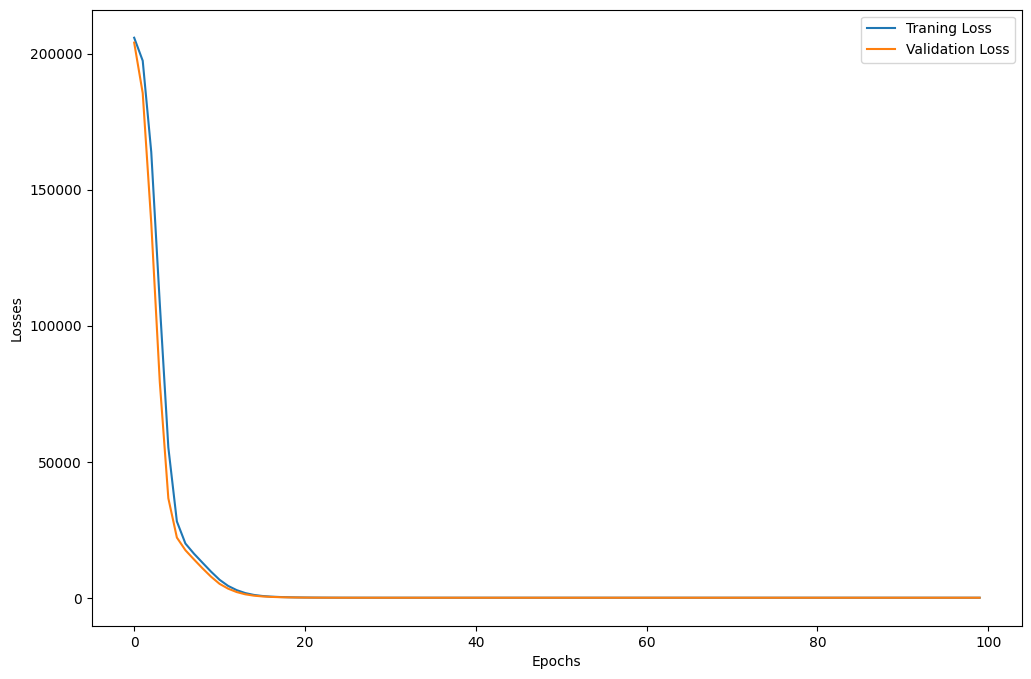

In [169]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"], label= ["Traning Loss"])
plt.plot(loss_df["Validation Loss"], label= ["Validation Loss"])

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()


In [170]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [172]:
# Evaluate our Model

model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.681068420410156
Testing MSE: 18.844329833984375


In [173]:
from sklearn.metrics import r2_score

print("r2 score:", r2_score(y_test, test_preds))

r2 score: 0.9341439285309628


In [174]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.382111,433.27
1,436.874237,438.16
2,461.213196,458.42
3,475.981964,480.82
4,435.621735,441.41
...,...,...
1909,451.090454,456.70
1910,431.668365,438.04
1911,467.525726,467.80
1912,431.131958,437.14
